In [1]:
# setup
import sys
import os

sys.path.append(os.path.abspath(".."))

# ICVul
import pandas as pd

from utils.stats import run_stats

# Load the datasets
df_labels = pd.read_csv('../data/intermediate/commits_icvul.csv')
df_metrics = pd.read_csv('../data/intermediate/churn_icvul_semantic.csv')

# Merge the dataframes
df_vuln = pd.merge(
    df_labels.drop(columns=['commit_role'], errors='ignore'), 
    df_metrics, 
    on='commit_id',
    how='inner',
)

df_vuln['Dataset'] = 'Vulnerability'
df_vuln['Type'] = df_vuln['commit_role'].map({'VIC': 'Inducing', 'VFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

In [2]:
# KFC (Linux)
import pandas as pd

# Load the datasets
df_churn = pd.read_csv('../data/intermediate/churn_linux_semantic.csv')
df_labels = pd.read_csv('../data/intermediate/commits_dataset_linux.csv')

# Merge the datasets
# We drop 'commit_role' from df_churn so it doesn't conflict with df_labels
df_bug = pd.merge(
    df_labels, 
    df_churn.drop(columns=['commit_role'], errors='ignore'), 
    on='commit_id', 
    how='inner'
)

df_bug['Dataset'] = 'Bug'
df_bug['Type'] = df_bug['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

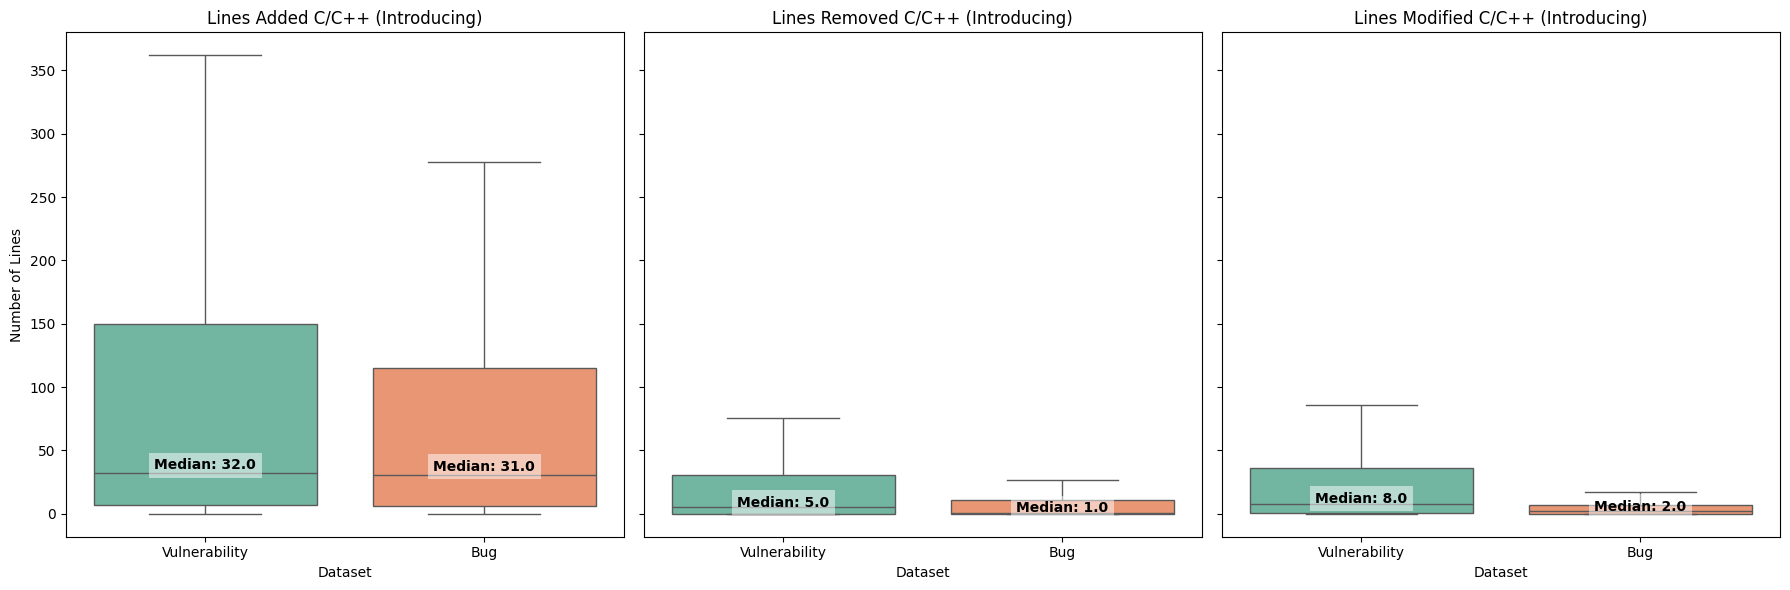


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 0.02848      |   0.053 (negligible) | 
Lines Removed      | 1.76e-19     |   0.210 (small     ) | *
Lines Modified     | 1.51e-56     |   0.375 (medium    ) | *


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for only 'Fixing' commits (Ensure df_vuln and df_bug are your C/C++ data)
df_introducing = pd.concat([
    df_vuln[(df_vuln['commit_role'] == 'VIC') & (df_vuln['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']],
    df_bug[(df_bug['commit_role'] == 'BIC') & (df_bug['lines_added'] < 10000)][['lines_added', 'lines_removed', 'lines_modified', 'Dataset']]
])

# 2. Create the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added C/C++ (Introducing)', 'Lines Removed C/C++ (Introducing)', 'Lines Modified C/C++ (Introducing)']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=df_introducing, 
        x='Dataset', 
        y=metric, 
        hue='Dataset',
        ax=ax,
        showfliers=False, 
        palette="Set2",
        legend=False
    )
    
    # --- Logic to add Median Labels ---
    # We calculate medians grouped by Dataset for the specific metric
    medians = df_introducing.groupby('Dataset')[metric].median()
    
    # Get the x-tick positions (0 for first box, 1 for second)
    for xtick in range(len(ax.get_xticklabels())):
        dataset_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[dataset_name]
        
        ax.text(
            xtick, 
            m_val * 1.1 if m_val > 0 else 0.1, 
            f'Median: {m_val:.1f}', 
            horizontalalignment='center', 
            size='medium', 
            color='black', 
            weight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
        )
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')

plt.tight_layout()
plt.show()

run_stats(df_introducing)

In [4]:
# TOSEM
import pandas as pd

# 1. Load the manual vulnerability dataset
df_vuln_java = pd.read_csv('../data/intermediate/churn_tosem_semantic.csv')

# 2. Group by Type (VFC/VIC) and calculate stats
metrics = ['lines_added', 'lines_removed', 'lines_modified']
vuln_stats = df_vuln_java.groupby('commit_role')[metrics].agg(['median', 'mean', 'count'])

df_java_vfc_only = df_vuln_java[df_vuln_java['commit_role'] == 'VFC'].copy()
df_java_vic_only = df_vuln_java[df_vuln_java['commit_role'] == 'VIC'].copy()
df_java_vfc_only['Group'] = 'Java Vulnerability (Manual)'

In [5]:
# DS_APACHE
import pandas as pd

df_bug_java = pd.read_csv('../data/intermediate/churn_ds_apache_semantic.csv')

df_bug_java['Dataset'] = 'Bug'
df_bug_java['Type'] = df_bug_java['commit_role'].map({'BIC': 'Inducing', 'BFC': 'Fixing'})

metrics = ['lines_added', 'lines_removed', 'lines_modified']

df_java_bfc_only = df_bug_java[df_bug_java['commit_role'] == 'BFC'].copy()
df_java_bic_only = df_bug_java[df_bug_java['commit_role'] == 'BIC'].copy()

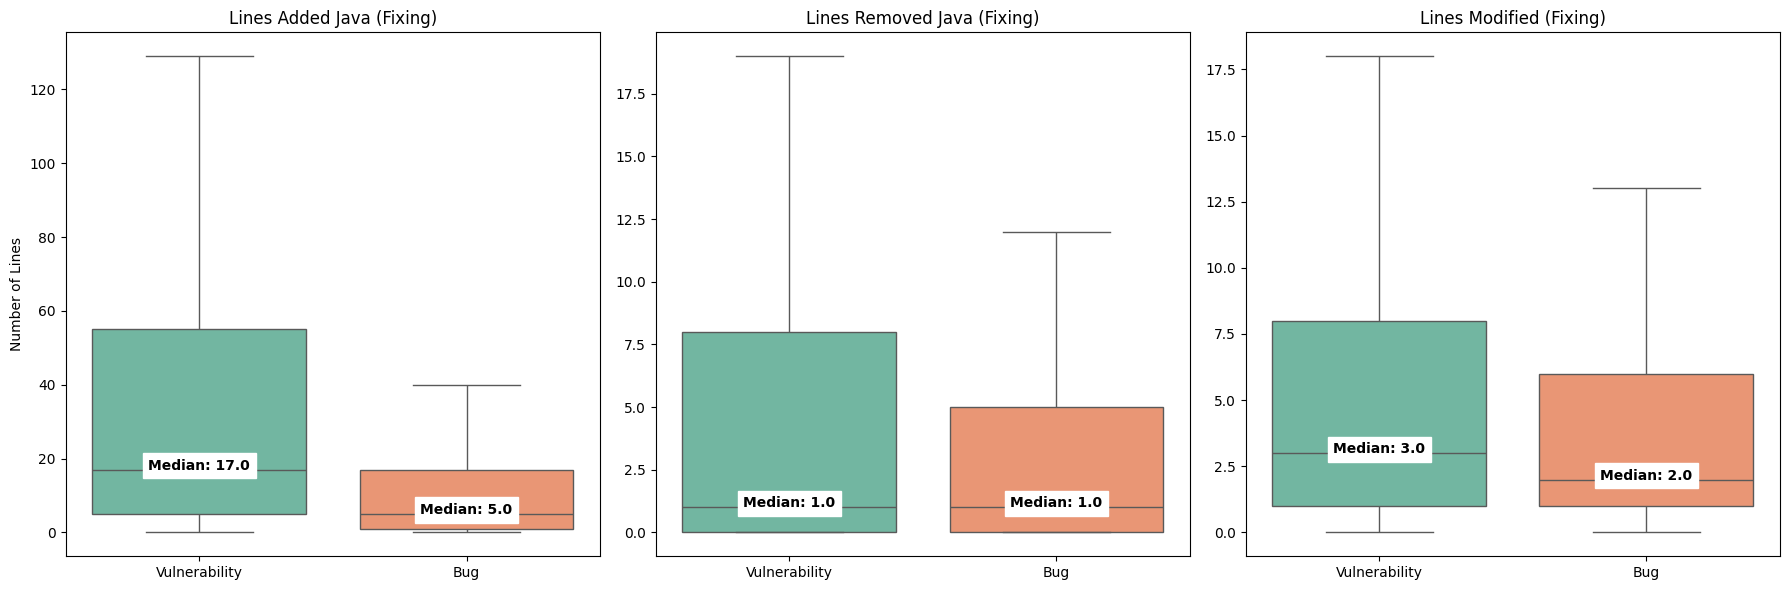


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 4.88e-09     |   0.349 (medium    ) | *
Lines Removed      | 0.85986      |  -0.010 (negligible) | 
Lines Modified     | 0.65308      |   0.027 (negligible) | 


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vfc_only.copy()
df_b = df_java_bfc_only.copy()

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Fixing)', 'Lines Removed Java (Fixing)', 'Lines Modified (Fixing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp)

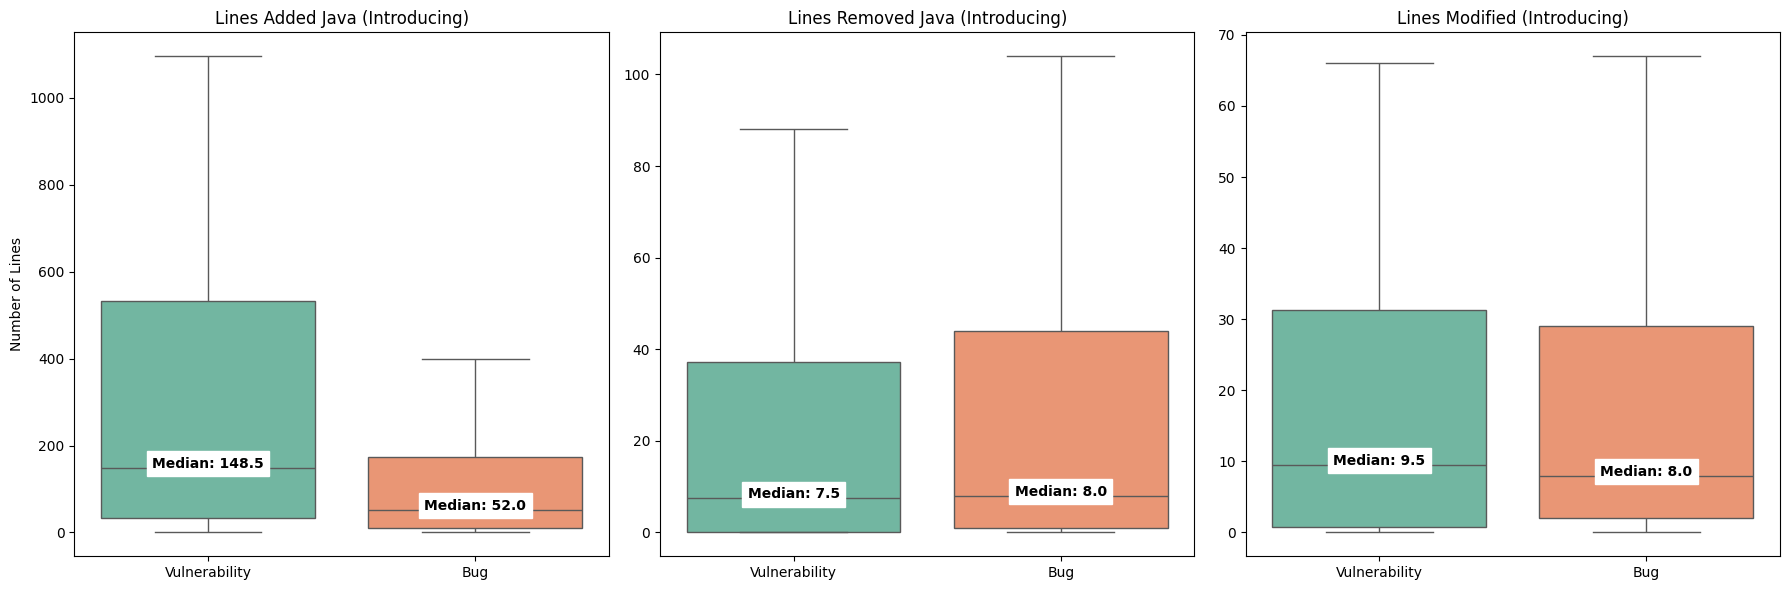


MANN-WHITNEY U TEST & CLIFF'S DELTA (Vulnerability vs. Bug)

Bonferroni-corrected alpha: 0.0167

Metric             | p-value      | Cliff’s Delta        | Sig
----------------------------------------------------------------------
Lines Added        | 4.37e-05     |   0.293 (small     ) | *
Lines Removed      | 0.47718      |  -0.051 (negligible) | 
Lines Modified     | 0.38340      |  -0.062 (negligible) | 


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use the DataFrames you already have for Java fixes
df_v = df_java_vic_only.copy()
df_v = df_v[df_v['lines_added'] < 10000]
df_b = df_java_bic_only.copy()
df_b = df_b[df_b['lines_added'] < 10000]

# Ensure labels match for the X-axis
df_v['Dataset'] = 'Vulnerability'
df_b['Dataset'] = 'Bug'

df_java_comp_i = pd.concat([df_v, df_b])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # sharey=False can help if Added is much larger than Removed

metrics = ['lines_added', 'lines_removed', 'lines_modified']
titles = ['Lines Added Java (Introducing)', 'Lines Removed Java (Introducing)', 'Lines Modified (Introducing)']

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df_java_comp_i, x='Dataset', y=m, hue='Dataset', 
                ax=ax, showfliers=False, palette="Set2", legend=False)
    
    # Add Median Labels
    medians = df_java_comp_i.groupby('Dataset')[m].median()
    for xtick in range(len(ax.get_xticklabels())):
        ds_name = ax.get_xticklabels()[xtick].get_text()
        m_val = medians[ds_name]
        ax.text(xtick, m_val, f'Median: {m_val:.1f}', 
                ha='center', weight='bold', backgroundcolor='white')
    
    ax.set_title(titles[i])
    ax.set_ylabel('Number of Lines' if i == 0 else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

run_stats(df_java_comp_i)